In [ ]:
!pip install kagglehub

In [ ]:
# Upload kaggle.json file
from google.colab import files
import os

# Upload the kaggle.json file
print("Please upload your kaggle.json file:")
uploaded = files.upload()

# Create the .kaggle directory if it doesn't exist
kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)

# Move the uploaded file to the correct location
for filename in uploaded.keys():
    if filename == 'kaggle.json':
        destination = os.path.join(kaggle_dir, 'kaggle.json')
        with open(destination, 'wb') as f:
            f.write(uploaded[filename])

        # Set proper permissions (chmod 600)
        os.chmod(destination, 0o600)
        print(f"✓ kaggle.json uploaded and configured successfully!")
        print(f"  Location: {destination}")
    else:
        print(f"Warning: Expected 'kaggle.json' but got '{filename}'")

# Verify installation
try:
    import kagglehub
    print("\n✓ kagglehub is ready to use!")
except ImportError:
    print("\n! kagglehub not found. Installing...")
    !pip install kagglehub
    print("✓ kagglehub installed successfully!")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
✓ kaggle.json uploaded and configured successfully!
  Location: /root/.kaggle/kaggle.json

✓ kagglehub is ready to use!


In [ ]:
!kaggle competitions download -c fsdm-classification-2025-2026-fruit-vision

  0% 0.00/8.72M [00:00<?, ?B/s]
100% 8.72M/8.72M [00:00<00:00, 1.02GB/s]


In [ ]:
!unzip fsdm-classification-2025-2026-fruit-vision.zip

Archive:  fsdm-classification-2025-2026-fruit-vision.zip
  inflating: Fruit_dataset_2 classes/Fruit_dataset_2 classes/test/222.jpg  
  inflating: Fruit_dataset_2 classes/Fruit_dataset_2 classes/test/354.jpg  
  inflating: Fruit_dataset_2 classes/Fruit_dataset_2 classes/test/372.jpg  
  inflating: Fruit_dataset_2 classes/Fruit_dataset_2 classes/test/466.jpg  
  inflating: Fruit_dataset_2 classes/Fruit_dataset_2 classes/test/482.jpg  
  inflating: Fruit_dataset_2 classes/Fruit_dataset_2 classes/test/539.jpg  
  inflating: Fruit_dataset_2 classes/Fruit_dataset_2 classes/test/55.jpg  
  inflating: Fruit_dataset_2 classes/Fruit_dataset_2 classes/test/568.jpg  
  inflating: Fruit_dataset_2 classes/Fruit_dataset_2 classes/test/602.jpg  
  inflating: Fruit_dataset_2 classes/Fruit_dataset_2 classes/test/618.jpg  
  inflating: Fruit_dataset_2 classes/Fruit_dataset_2 classes/test/62.jpg  
  inflating: Fruit_dataset_2 classes/Fruit_dataset_2 classes/test/66.jpg  
  inflating: Fruit_dataset_2 class

In [ ]:
import cv2
import numpy as np
import pandas as pd
from skimage import feature, filters, measure
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# déclarer le dossier de base
base_path='/content/Fruit_dataset_2 classes/Fruit_dataset_2 classes'

#Visualisation de quelques images de la base d'apprentissage (train)



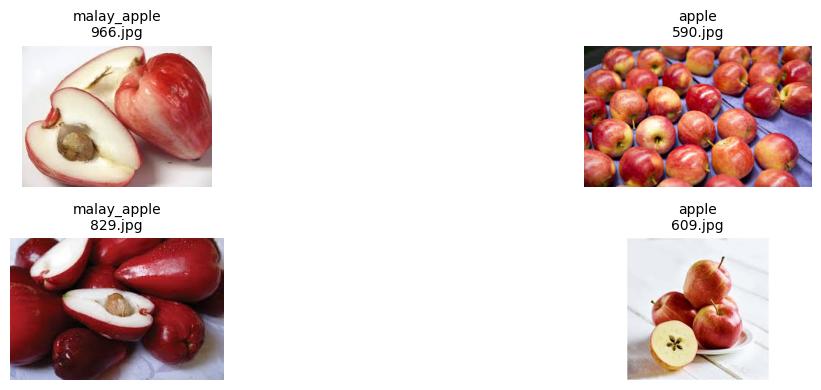

In [ ]:
import matplotlib.pyplot as plt
import random
import os
from PIL import Image

def display_random_images(train_path, num_images=4):
    """Afficher des images aléatoires du dataset d'entraînement"""
    # Obtenir tous les chemins d'images
    all_images = []
    class_names = ['apple', 'malay_apple']

    for class_name in class_names:
        class_path = os.path.join(train_path, class_name)
        if os.path.exists(class_path):
            for img_file in os.listdir(class_path):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    all_images.append((os.path.join(class_path, img_file), class_name))
    # Sélectionner aléatoirement
    selected_images = random.sample(all_images, min(num_images, len(all_images)))

    # Afficher les images
    fig, axes = plt.subplots(2, 2, figsize=(15, 4))
    axes = axes.ravel()

    for idx, (img_path, class_name) in enumerate(selected_images):
        try:
            img = Image.open(img_path)
            axes[idx].imshow(img)
            axes[idx].set_title(f'{class_name}\n{os.path.basename(img_path)}', fontsize=10)
            axes[idx].axis('off')
        except Exception as e:
            print(f"Erreur avec l'image {img_path}: {e}")
            axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

  # Utilisation
display_random_images(base_path+'/train', num_images=4)

#Extraction des caractéristiques Couleur, Texture, Forme



In [ ]:
import cv2
import numpy as np
from skimage import feature, color

 #  1. Caractéristiques de COULEUR
def extract_color_features(image):
    """
    Extrait des caractéristiques basées sur la couleur.
    → Utilise des histogrammes HSV (Teinte, Saturation, Valeur)
    """
    # Convertir l'image en espace de couleur HSV
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Calculer les histogrammes pour chaque canal (H, S, V)
    hist_h = cv2.calcHist([hsv], [0], None, [16], [0, 180])  # Teinte
    hist_s = cv2.calcHist([hsv], [1], None, [16], [0, 256])  # Saturation
    hist_v = cv2.calcHist([hsv], [2], None, [16], [0, 256])  # Valeur

    # Concaténer les 3 histogrammes
    features = np.concatenate([hist_h, hist_s, hist_v]).flatten()

    # Normaliser (pour éviter l'influence de la taille de l'image)
    features = features / np.sum(features)

    return features

 #  2. Caractéristiques de TEXTURE
def extract_texture_features(image):
    """
    Extrait des caractéristiques basées sur la texture.
    → Utilise le descripteur LBP (Local Binary Pattern)
    """
    # Convertir en niveaux de gris
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Calculer le LBP avec 8 voisins et un rayon de 1
    lbp = feature.local_binary_pattern(gray, P=8, R=1, method="uniform")

    # Créer un histogramme des motifs LBP
    (hist, _) = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, 11),  # 10 motifs "uniformes" + 1
        range=(0, 10)
    )

    # Normaliser l'histogramme
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)

    features = hist
    return features


#  3. Caractéristiques de FORME

def extract_shape_features(image):
    """
    Extrait des caractéristiques basées sur la forme.
    → Utilise les moments de Hu (invariants à la rotation et l’échelle)
    """
    # Convertir en niveaux de gris
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Binarisation pour bien détecter la forme
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Calcul des moments
    moments = cv2.moments(thresh)
    hu = cv2.HuMoments(moments).flatten()

    # Transformation logarithmique pour stabiliser les valeurs
    hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-7)

    features = hu
    return features


In [ ]:
def extract_all_features(image_path):
    """Extract all features from an image"""
    try:
        # Read image
        image = cv2.imread(image_path)
        if image is None:
            print(f"Warning: Could not read image {image_path}")
            return None

        # Resize image for consistency (optional)
        # image = cv2.resize(image, (256, 256))

        all_features = []

        # Extract different types of features
        all_features.extend(extract_color_features(image))
        all_features.extend(extract_texture_features(image))
        all_features.extend(extract_shape_features(image))
        return all_features

    except Exception as e:
        print(f"Error processing {image_path}: {str(e)}")
        return None

#Chargement des données et Features Extraction



In [ ]:
def load_dataset_and_extract_features(base_path, dataset_type='train'):
    """Load dataset and extract features"""
    features_list = []
    labels_list = []

    class_mapping = {'apple': 0, 'malay_apple': 1}

    for class_name, class_label in class_mapping.items():
        class_path = os.path.join(base_path, dataset_type, class_name)

        if not os.path.exists(class_path):
            print(f"Warning: Path {class_path} does not exist")
            continue

        print(f"Processing {class_name} images...")
        for image_file in tqdm(os.listdir(class_path)):
            if image_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_path = os.path.join(class_path, image_file)
                #print(image_path)
                features = extract_all_features(image_path)

                if features is not None:
                    features_list.append(features)
                    labels_list.append(class_label)

    return np.array(features_list), np.array(labels_list)

In [ ]:
# Extract features pour training
print("Extracting training features...")
X_train, y_train = load_dataset_and_extract_features(base_path, 'train')

print(f"Training features shape: {X_train.shape}")

# Extract features pour validation
print("Extracting validation features...")
X_val, y_val = load_dataset_and_extract_features(base_path, 'val')

print(f"Validation features shape: {X_val.shape}")

Extracting training features...
Processing apple images...


100%|██████████| 388/388 [00:06<00:00, 61.81it/s]


Processing malay_apple images...


100%|██████████| 390/390 [00:05<00:00, 71.04it/s]


Training features shape: (778, 65)
Extracting validation features...
Processing apple images...


100%|██████████| 50/50 [00:00<00:00, 87.79it/s]


Processing malay_apple images...


100%|██████████| 50/50 [00:00<00:00, 76.50it/s]

Validation features shape: (100, 65)


#Feature Preprocessing et Entrainement du Modèle





In [ ]:

# A completer
# Conversion en array numpy si ce n’est pas déjà le cas
X_train = np.array(X_train)
X_val = np.array(X_val)

# Normalisation / Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_val_scaled shape: {X_val_scaled.shape}")


X_train_scaled shape: (778, 65)
X_val_scaled shape: (100, 65)


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(n_estimators=300, learning_rate=0.1, max_depth=4, random_state=42)
model.fit(X_train_scaled, y_train)
y_val_pred = model.predict(X_val_scaled)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred, target_names=['apple', 'malay_apple']))

Validation Accuracy: 0.81
              precision    recall  f1-score   support

       apple       0.84      0.76      0.80        50
 malay_apple       0.78      0.86      0.82        50

    accuracy                           0.81       100
   macro avg       0.81      0.81      0.81       100
weighted avg       0.81      0.81      0.81       100



In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

estimators = [
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)),
    ('svm', SVC(probability=True, kernel='rbf', C=1.0, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42))
]

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stacking_clf.fit(X_train_scaled, y_train)
y_pred_stack = stacking_clf.predict(X_val_scaled)

from sklearn.metrics import accuracy_score, classification_report
print("Accuracy (Stacking):", accuracy_score(y_val, y_pred_stack))
print(classification_report(y_val, y_pred_stack))


Accuracy (Stacking): 0.82
              precision    recall  f1-score   support

           0       0.83      0.80      0.82        50
           1       0.81      0.84      0.82        50

    accuracy                           0.82       100
   macro avg       0.82      0.82      0.82       100
weighted avg       0.82      0.82      0.82       100



Accuracy (Random Forest): 0.78
              precision    recall  f1-score   support

           0       0.79      0.76      0.78        50
           1       0.77      0.80      0.78        50

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.78      0.78      0.78       100



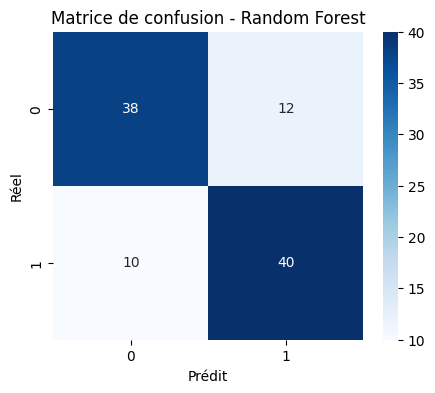

Accuracy (SVM): 0.81
              precision    recall  f1-score   support

           0       0.79      0.84      0.82        50
           1       0.83      0.78      0.80        50

    accuracy                           0.81       100
   macro avg       0.81      0.81      0.81       100
weighted avg       0.81      0.81      0.81       100



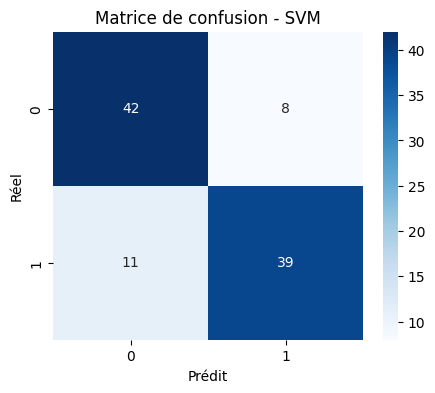

Accuracy (XGBoost): 0.8
              precision    recall  f1-score   support

           0       0.81      0.78      0.80        50
           1       0.79      0.82      0.80        50

    accuracy                           0.80       100
   macro avg       0.80      0.80      0.80       100
weighted avg       0.80      0.80      0.80       100



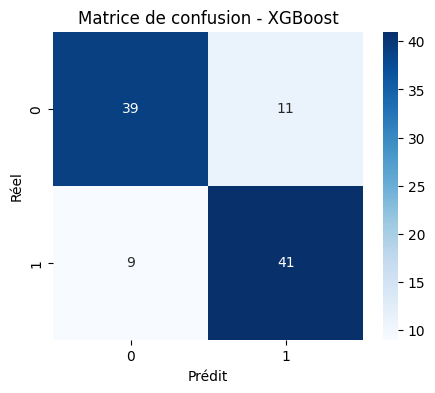

Accuracy (Stacking): 0.82
              precision    recall  f1-score   support

           0       0.83      0.80      0.82        50
           1       0.81      0.84      0.82        50

    accuracy                           0.82       100
   macro avg       0.82      0.82      0.82       100
weighted avg       0.82      0.82      0.82       100



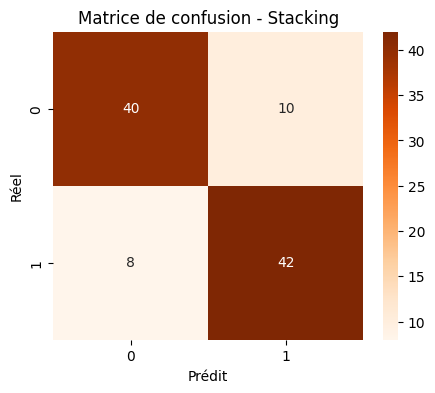

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Affichage des matrices de confusion pour chaque base learner


models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42),
    "SVM": SVC(probability=True, kernel='rbf', C=1.0, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)

    print(f"Accuracy ({name}):", accuracy_score(y_val, y_pred))
    print(classification_report(y_val, y_pred))

    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"Matrice de confusion - {name}")
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.show()


#Stacking

estimators = [
    ('rf', models['Random Forest']),
    ('svm', models['SVM']),
    ('xgb', models['XGBoost'])
]

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stacking_clf.fit(X_train_scaled, y_train)
y_pred_stack = stacking_clf.predict(X_val_scaled)

print("Accuracy (Stacking):", accuracy_score(y_val, y_pred_stack))
print(classification_report(y_val, y_pred_stack))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_val, y_pred_stack), annot=True, fmt='d', cmap='Oranges')
plt.title("Matrice de confusion - Stacking")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()


#Prédiction des classes de la base de test


In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

 #  Fonction pour charger les images du dossier test plat
def load_test_images_flat(test_path):
    features_list = []
    filenames = []

    for image_file in os.listdir(test_path):
        if image_file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_path = os.path.join(test_path, image_file)
            features = extract_all_features(image_path)
            if features is not None:
                features_list.append(features)
                filenames.append(image_file)

    return np.array(features_list), filenames

#  Chemin du dossier test
test_path = os.path.join(base_path, 'test')
# Extraction des features
print("Extracting test features...")
X_test, test_filenames = load_test_images_flat(test_path)
print(f"Number of test images loaded: {X_test.shape[0]}")

if X_test.shape[0] == 0:
    raise ValueError("Aucune image valide dans le dossier test !")

# Scaling des features test
X_test_scaled = scaler.transform(X_test)  # scaler entraîné sur X_train
#  Prédiction avec Stacking
y_test_pred = stacking_clf.predict(X_test_scaled)
 #  Sauvegarde des résultats dans un CSV
test_results = pd.DataFrame({
    'Image': test_filenames,
    'Predicted_Class': y_test_pred
})

csv_path = 'stacking_test_predictions.csv'
test_results.to_csv(csv_path, index=False)
print(f"Predictions saved to {csv_path}")


Extracting test features...
Number of test images loaded: 22
Predictions saved to stacking_test_predictions.csv


In [ ]:
!ls "/content/Fruit_dataset_2 classes/Fruit_dataset_2 classes/test"


222.jpg  466.jpg  55.jpg   618.jpg  69.jpg   781.jpg  905.jpg  97.jpg
354.jpg  482.jpg  568.jpg  62.jpg   746.jpg  834.jpg  922.jpg  desktop.ini
372.jpg  539.jpg  602.jpg  66.jpg   757.jpg  881.jpg  970.jpg


#Créer le fichier de soumission et le sauvegarder dans le dossier Output

Par la suite, il faut faire la soumission avec votre fichier csv

In [ ]:
# Calculer les probabilités pour chaque classe
test_probabilities = stacking_clf.predict_proba(X_test_scaled)  # X_test_scaled = features test normalisées


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd


# Fonction d’extraction des features

def load_test_features(test_dir):
    feats = []
    names = []
    for fname in sorted(os.listdir(test_dir)):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        fpath = os.path.join(test_dir, fname)
        # img = cv2.imread(fpath) # No need to read image here, extract_all_features does it
        # if img is None:
        #     continue
        f = extract_all_features(fpath)   # Call your feature extraction function with the image path
        if f is not None: # Check if feature extraction was successful
          feats.append(f)
          names.append(fname)
    if len(feats) == 0:
        return np.empty((0, 65)), [] # Return empty array with correct shape
    feats = np.array(feats, dtype=np.float32)
    return feats, names



# Chargement et extraction test

print(">>> Extraction des features test ...")
test_path = os.path.join(base_path, 'test') # Define test_path
X_test, test_filenames = load_test_features(test_path)

# Normalisation
X_test_scaled = scaler.transform(X_test)
# No need for PCA based on previous cells
# X_test_pca = pca.transform(X_test_scaled)


# Prédiction sur le test

# Use stacking_clf from previous cells
y_test_pred = stacking_clf.predict(X_test_scaled)
test_probabilities = stacking_clf.predict_proba(X_test_scaled)

# Mapper les labels numériques en noms de classes
label_map = {0: 'apple', 1: 'malay_apple'}
y_test_pred_mapped = pd.Series(y_test_pred).map(label_map)

# Créer le dossier de sortie s’il n’existe pas
output_dir = './submission'
os.makedirs(output_dir, exist_ok=True)


# Construction du CSV final

submission = pd.DataFrame({
    'id': [os.path.splitext(name)[0] for name in test_filenames],   # "222.jpg" → "222"
    'class': y_test_pred_mapped,

})


# Sauvegarder le CSV au format attendu
csv_path = os.path.join(output_dir, 'submission_class_fruit.csv')
submission[['id', 'class']].to_csv(csv_path, index=False)  # retirer l'espace

print(f" Fichier de soumission généré : {csv_path}")
print(submission.head())

>>> Extraction des features test ...
 Fichier de soumission généré : ./submission/submission_class_fruit.csv
    id        class
0  222  malay_apple
1  354  malay_apple
2  372  malay_apple
3  466        apple
4  482  malay_apple
